<a href="https://colab.research.google.com/github/Ekoink/movie-trends-analysis/blob/main/Netflix_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Trends Analysis


This Netflix dataset has information on all the TV shows and movies available on Netflix till 2021. The dataset is collected from Flixable, a third-party Netflix search engine and is available on Kaggle for free.

I chose this dataset to analyse how Netflix's content has changed over time. This will look at the shifts in the type of content released by Netflix, the regions most represented and try to spot any main patterns that may have emerged in Netflix's catalogue over time.

I also chose this project as a way to practice data cleaning, analysis and visualisation on data from a real entertainment dataset. This would help me apply the concepts I have studied and develop essential skills to tackle other data science projects in the future.


# Research Questions:

The main question is this:

How has Netflix evolved its content strategy over time?

Here are the follow up questions we will be finding fromt he dataset.

1. In which years was the most content released that's now on Netflix?
2.  What's the age distribution of Netflix's content library over time?
3. What's the trend in content duration over the years? (movie lengths, TV season counts)
4. Which ratings (TV-MA, PG-13, etc.) dominate Netflix's catalog and how has this changed?
5. How do ratings correlate with genre preferences?
6. How diverse is Netflix's content geographically - are they expanding into new markets?
7. Which countries specialize in which genres? (clustering analysis)
8. Are there seasonal patterns in when content was originally released? (using release dates)
9. What's the relationship between content duration and genre popularity?

In [ ]:
# Step 1: Import the libraries
import pandas as pd
from google.colab import files

# Step 2: Upload your file
uploaded = files.upload()  # This will open a file picker in Colab

# Step 3: Get the uploaded file name
file_name = list(uploaded.keys())[0]  # grabs the first uploaded file

# Step 4: Load the CSV into pandas
data = pd.read_csv("Netflix Dataset.csv")

# Step 5: Check the first few rows
#print(df.head())
print(data)

Saving Netflix Dataset.csv to Netflix Dataset (2).csv
     Show_Id Category                                    Title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                    07:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
...      ...      ...                                      ...   
7784   s7783    Movie                                     Zozo   
7785   s7784    Movie                                   Zubaan   
7786   s7785    Movie                        Zulu Man in Japan   
7787   s7786  TV Show                    Zumbo's Just Desserts   
7788   s7787    Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               Director                                               Cast  \
0                   NaN  João Miguel, Bianca Comparato, Michel Gomes, R... 

# Information about the Dataset

To begin, I uploaded the dataset into the Google Colab environment and used the Pandas library to load it. To understand the structure of the dataset, I displayed the first and last five rows (using the head() and tail() functions), confirmed that there are 11 columns, and checked the dataset’s shape to see the total number of rows and columns.

Next, I will obtain some basic information from the dataset using specific functions.

We will obtain some basic information from the dataset using specific functions.

The head function shows the first five rows of the dataset, allowing us to see a quick overview of its structure.

In [ ]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


We also use the tail function to view the last five rows of the dataset. This ensures that the dataset loads correctly across the full range.

In [ ]:
data.tail()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


We then check the table's shape to know the total number of rows and columns in the table.

In [ ]:
data.shape

(7789, 11)

To determine the number of elements in the dataset, we use the size function below.

In [ ]:
data.size

85679

We check the dataset’s column names using the columns attribute to understand what features are available for analysis.

In [ ]:
data.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

Now, we use a function to find the data types of each column. The function is dtypes.

In [ ]:
data.dtypes

,0
Show_Id,object
Category,object
Title,object
Director,object
Cast,object
Country,object
Release_Date,object
Rating,object
Duration,object
Type,object


We then use the info() function to get a summary of the dataset including the column names, data types, number of non-null values adn the memory usage.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


So we've used those basic functions to gather information about the data set.

#Cleaning the Dataset
Now, we have to clean the dataset to make it more accurate. This means addressing missing values, duplicate entries and inconsistent formatting in the dataset.


**Removing Duplicate Values:**

We'll check for duplicate rows in the dataset using the duplicated() function. But before that, showing the first few rows with head() gives us a quick preview of the data before cleaning.

In [ ]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


Checking the shape of the database before cleaning gives us a value to compare with after cleaning. It gives us a baseline to work with and confirms how much smaller the dataset got.

In [ ]:
print(f"Original dataset shape: {data.shape}")

Original dataset shape: (7789, 11)


We filter the dataset with the data.duplicated() to directly view the duplicate rows.

In [ ]:
data[data.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,"April 5, 2019",TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,"September 4, 2020",TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


We then remove all duplicates from the dataset permanently.

In [ ]:
data.drop_duplicates(inplace=True)

To ensure they were actually removed, we can run the data.duplicated() again. We can also compare the shape of the dataset now to the previous shape.

In [ ]:
data[data.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description


In [ ]:
print(f"Dataset shape after removing duplicates: {data.shape}")

Dataset shape after removing duplicates: (7787, 13)


As you can see, the data.duplicated() didn't show anything, meaning that all the duplicated rows it found before have been removed. Equally, the data shape has become smaller by the number of duplicated rows.

**Identifying Null Values**

Here we check for null values using the isnull() function and visualise it using a heatmap.

In [ ]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
data.isnull()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
7784,False,False,False,False,False,False,False,False,False,False,False
7785,False,False,False,False,False,False,False,False,False,False,False
7786,False,False,False,True,False,True,False,False,False,False,False
7787,False,False,False,True,False,False,False,False,False,False,False


This function shows the null values using true or false. It's inconvenient to manually go through it, so we sum the results using the sum() function.

In [ ]:
data.isnull().sum()

,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


To show the heat map, we're going to need the Seaborn library.

In [ ]:
import seaborn as sns

<Axes: >

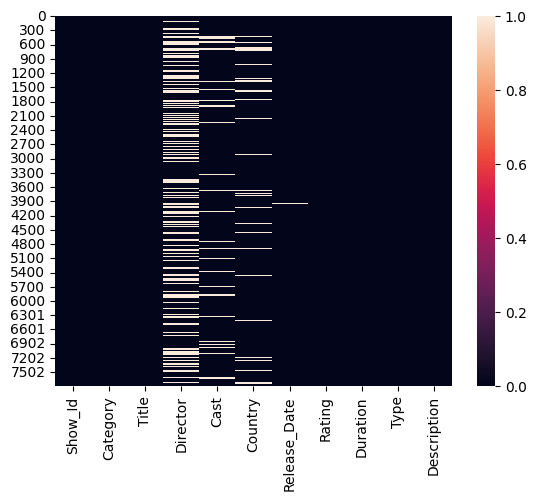

In [ ]:
sns.heatmap(data.isnull())

# Analysis Sections

Let's dive into the questions we need answered by the dataset.

**Q1.** In which years was the most content released that's now on Netflix?


There are two methods to solve this question. Let's go through them both.

In [ ]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


First, we'll go through all the column names, and then use an if statement to identify any columns that will have date information.

In [ ]:
#First let's  all the column names
print("All columns in the dataset:")
print(data.columns.tolist())

All columns in the dataset:
['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country', 'Release_Date', 'Rating', 'Duration', 'Type', 'Description', 'Date_N', 'Year']


In [ ]:
# Let's also check if there are any columns that might contain "added" or "date"
print("\nColumns that might contain date information:")
for col in data.columns:
    if 'date' in col.lower() or 'added' in col.lower() or 'year' in col.lower():
        print(f"- {col}")


Columns that might contain date information:
- Release_Date
- Date_N
- Year


In [ ]:
data[data['Title'].isin(['House of Cards'])]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
2832,s2833,TV Show,House of Cards,"Robin Wright, David Fincher, Gerald McRaney, J...","Kevin Spacey, Robin Wright, Kate Mara, Corey S...",United States,"November 2, 2018",TV-MA,6 Seasons,"TV Dramas, TV Thrillers",A ruthless politician will stop at nothing to ...


This way, we can say the Show_Id is s2833, and the Director is Robin Wright, David Fincher, Gerald McRaney, J...etc.

In [ ]:
data[data['Title'].str.contains('House of Cards')]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
2832,s2833,TV Show,House of Cards,"Robin Wright, David Fincher, Gerald McRaney, J...","Kevin Spacey, Robin Wright, Kate Mara, Corey S...",United States,"November 2, 2018",TV-MA,6 Seasons,"TV Dramas, TV Thrillers",A ruthless politician will stop at nothing to ...
